In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage import data, transform
from scipy.ndimage import gaussian_filter
import json

np.random.seed(0)
plt.rcParams['figure.dpi'] = 110

# PARAMETER BLOCK 
# All lengths in micrometers (um) 
WAVELENGTH_UM   = 0.532      # 532 nm
MAG             = 2.0        # system magnification
CAM_PIXEL_UM    = 2.5        # physical camera pixel pitch
EFF_PIXEL_UM    = CAM_PIXEL_UM / MAG   # effective pixel size at the object plane

N_LR            = 128        # simulated low-res (captured) grid size
DS              = 4          # oversampling factor for the high-res "ground truth" field
N_HR            = N_LR * DS  # high-res simulation grid
HR_PIXEL_UM     = EFF_PIXEL_UM / DS

# +/- 50 um 
# reported in the FPM literature (Zheng et al. 2013; Sun et al. 2004).
Z_RANGE_UM      = 50.0
Z_STEPS         = 161
Z_ARRAY_UM      = np.linspace(-Z_RANGE_UM, Z_RANGE_UM, Z_STEPS)

# Canonical NA sweep.
NA_LIST = [0.05, 0.08, 0.10, 0.15, 0.20, 0.25, 0.40, 0.60]

print("System parameters")
print(f"  wavelength        = {WAVELENGTH_UM} um")
print(f"  camera pixel      = {CAM_PIXEL_UM} um  (effective @ object plane = {EFF_PIXEL_UM:.3f} um)")
print(f"  N_LR / N_HR       = {N_LR} / {N_HR}  (oversampling ds = {DS})")
print(f"  camera Nyquist    = {1/(2*EFF_PIXEL_UM):.3f} 1/um")
print(f"  defocus sweep     = +/-{Z_RANGE_UM} um, {Z_STEPS} steps")
print(f"  NA sweep          = {NA_LIST}")

System parameters
  wavelength        = 0.532 um
  camera pixel      = 2.5 um  (effective @ object plane = 1.250 um)
  N_LR / N_HR       = 128 / 512  (oversampling ds = 4)
  camera Nyquist    = 0.400 1/um
  defocus sweep     = +/-50.0 um, 161 steps
  NA sweep          = [0.05, 0.08, 0.1, 0.15, 0.2, 0.25, 0.4, 0.6]


## 1. Test objects

Physical model as the original work: $O = A \cdot e^{i \varphi \cdot c}$, with amplitude
from the standard `cameraman` image and phase from a Gaussian-smoothed `moon` image. The phase
scale constant `c` is still a somewhat arbitrary knob rather than a real refractive-index x
thickness product, discussed here since it matters for how "weak" vs "strong"
is defined physically.

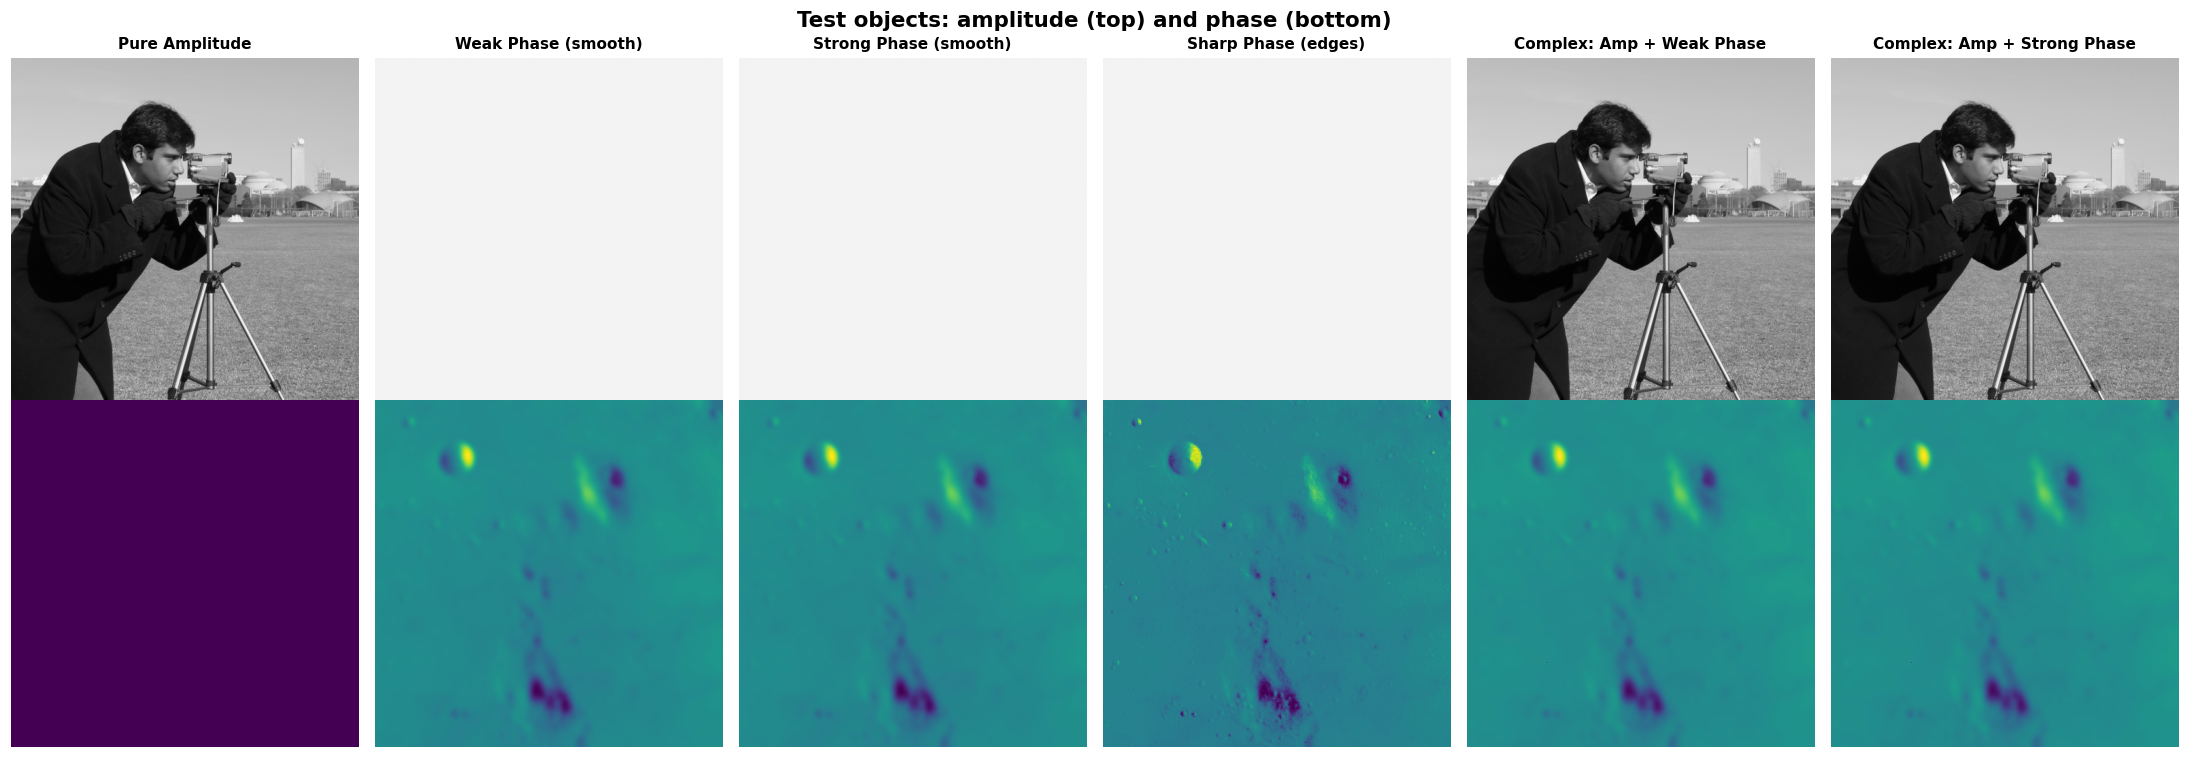

In [5]:
def make_objects(N):
    img_amp = transform.resize(data.camera(), (N, N), anti_aliasing=True)
    img_amp = img_amp / np.max(img_amp)

    img_phase_raw = transform.resize(data.moon(), (N, N), anti_aliasing=True)
    img_phase_smooth = gaussian_filter(img_phase_raw, sigma=4)
    img_phase_smooth = img_phase_smooth / np.max(img_phase_smooth)
    .

    objects = {
        "Pure Amplitude":            img_amp * np.exp(1j * np.zeros_like(img_amp)),
        "Weak Phase (smooth)":       np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 0.05)),
        "Strong Phase (smooth)":     np.ones((N, N)) * np.exp(1j * (img_phase_smooth * 1.5)),
        "Sharp Phase (edges)":       np.ones((N, N)) * np.exp(1j * (img_phase_sharp * 0.5)),
        "Complex: Amp + Weak Phase": img_amp * np.exp(1j * (img_phase_smooth * 0.5)),
        "Complex: Amp + Strong Phase": img_amp * np.exp(1j * (img_phase_smooth * 3.0)),
    }
    return objects

objects_hr = make_objects(N_HR)
object_names = list(objects_hr.keys())
colors = ['#1f77b4', '#2ca02c', '#d62728', '#ff7f0e', '#9467bd', '#8c564b']

fig, axes = plt.subplots(2, 6, figsize=(20, 7))
for i, (name, obj) in enumerate(objects_hr.items()):
    axes[0, i].imshow(np.abs(obj), cmap='gray', vmin=0, vmax=1.05)
    axes[0, i].set_title(name, fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    im = axes[1, i].imshow(np.angle(obj), cmap='viridis')#viridis, jet, gray, twilight
    axes[1, i].axis('off')
axes[0, 0].set_ylabel("Amplitude", fontsize=11)
axes[1, 0].set_ylabel("Phase", fontsize=11)
fig.suptitle("Test objects: amplitude (top) and phase (bottom)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("figs/fig_test_objects.png", dpi=150, bbox_inches='tight')
plt.show()

## 2. Angular-spectrum propagator and pupil apertures

FFT the full-resolution object once, then crop
the central `N_LR x N_LR` region of the spectrum and apply the pupil/defocus phase there. 

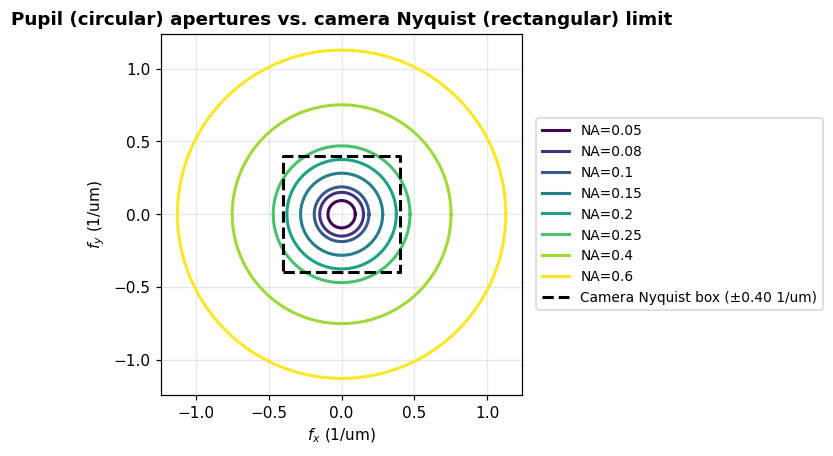

NA values whose pupil radius EXCEEDS the camera Nyquist box (aliasing-prone regime):
  NA=0.05  pupil radius=0.094 1/um
  NA=0.08  pupil radius=0.150 1/um
  NA=0.1   pupil radius=0.188 1/um
  NA=0.15  pupil radius=0.282 1/um
  NA=0.2   pupil radius=0.376 1/um
  NA=0.25  pupil radius=0.470 1/um  <-- pupil wider than camera Nyquist box
  NA=0.4   pupil radius=0.752 1/um  <-- pupil wider than camera Nyquist box
  NA=0.6   pupil radius=1.128 1/um  <-- pupil wider than camera Nyquist box


In [4]:
fx_lr = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
fy_lr = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
FX_LR, FY_LR = np.meshgrid(fx_lr, fy_lr)
K_RAD_LR = np.sqrt(FX_LR**2 + FY_LR**2)

cy, cx = N_HR // 2, N_HR // 2
ys, ye = cy - N_LR // 2, cy + N_LR // 2
xs, xe = cx - N_LR // 2, cx + N_LR // 2

CAMERA_NYQUIST = 1 / (2 * EFF_PIXEL_UM)

def pupil_and_kz(NA):
    pupil = (K_RAD_LR <= NA / WAVELENGTH_UM).astype(float)
    radicand = np.maximum((1.0 / WAVELENGTH_UM) ** 2 - FX_LR**2 - FY_LR**2, 0.0)
    kz = 2 * np.pi * np.sqrt(radicand)
    return pupil, kz

def propagate_stack(obj, NA, z_array_um):
    """Angular-spectrum defocus sweep. Returns intensity stack (len(z), N_LR, N_LR)."""
    O_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj)))
    O_crop = O_fourier[ys:ye, xs:xe]
    pupil, kz = pupil_and_kz(NA)
    stack = np.empty((len(z_array_um), N_LR, N_LR))
    for i, z in enumerate(z_array_um):
        pupil_z = pupil * np.exp(1j * z * kz)
        E_fourier = O_crop * pupil_z
        E_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_fourier)))
        stack[i] = np.abs(E_spatial) ** 2
    return stack

# Visualize the pupil footprints against the fixed camera-Nyquist (rectangular) box 
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
pupil_colors = plt.cm.viridis(np.linspace(0, 1, len(NA_LIST)))
for NA, c in zip(NA_LIST, pupil_colors):
    theta = np.linspace(0, 2*np.pi, 200)
    r = NA / WAVELENGTH_UM
    ax.plot(r*np.cos(theta), r*np.sin(theta), color=c, label=f"NA={NA}", linewidth=2)
box = CAMERA_NYQUIST
ax.plot([-box, box, box, -box, -box], [-box, -box, box, box, -box], 'k--', linewidth=2,
        label=f"Camera Nyquist box (±{box:.2f} 1/um)")
ax.set_xlabel("$f_x$ (1/um)"); ax.set_ylabel("$f_y$ (1/um)")
ax.set_title("Pupil (circular) apertures vs. camera Nyquist (rectangular) limit", fontweight='bold')
ax.set_aspect('equal')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig_pupil_vs_nyquist.png", dpi=150, bbox_inches='tight')
plt.show()

print("NA values whose pupil radius EXCEEDS the camera Nyquist box (aliasing-prone regime):")
for NA in NA_LIST:
    r = NA / WAVELENGTH_UM
    flag = "  <-- pupil wider than camera Nyquist box" if r > CAMERA_NYQUIST else ""
    print(f"  NA={NA:<5} pupil radius={r:.3f} 1/um{flag}")

## 3. Fourier content of the test objects 

Radial power spectral density puts the weak/strong/sharp phase objects on the same axis as the
two physical frequency limits (optical pupil cutoff and camera Nyquist), so we can see directly
which objects have energy sitting in the "collision zone" between the two limits, that's the
regime where clipping artifacts are expected regardless of which specific NA is chosen.

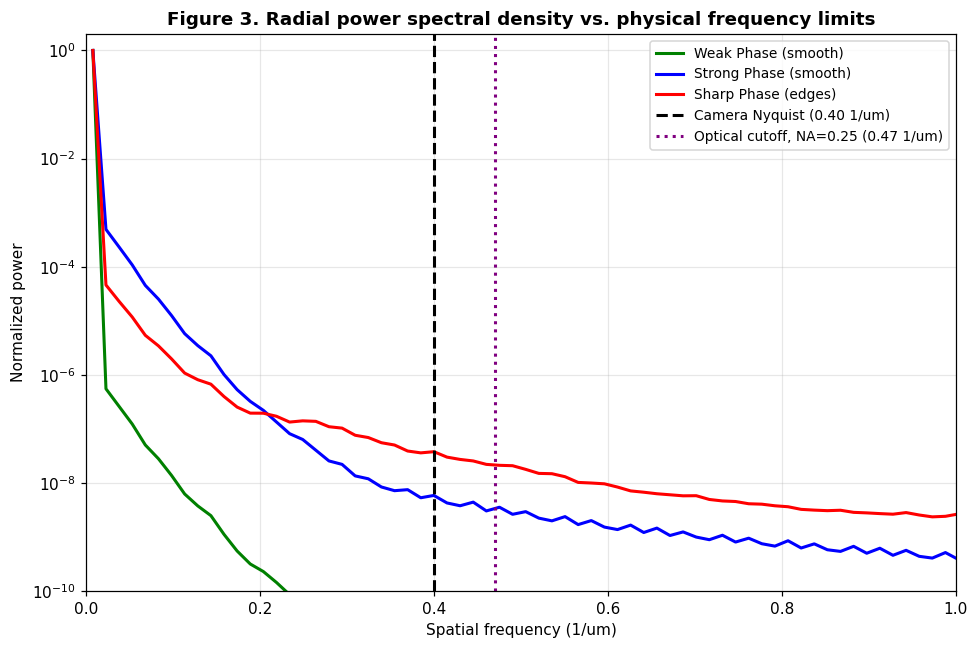

In [9]:
def radial_psd(field2d, k_rad_grid, bins=150):
    power = np.abs(field2d) ** 2
    r_flat = k_rad_grid.flatten()
    p_flat = power.flatten()
    edges = np.linspace(0, np.max(r_flat), bins + 1)
    centers = (edges[:-1] + edges[1:]) / 2
    out = np.zeros(bins)
    idx = np.digitize(r_flat, edges) - 1
    idx = np.clip(idx, 0, bins - 1)
    counts = np.bincount(idx, minlength=bins)
    sums = np.bincount(idx, weights=p_flat, minlength=bins)
    nz = counts > 0
    out[nz] = sums[nz] / counts[nz]
    return centers, out

fx_hr = np.fft.fftshift(np.fft.fftfreq(N_HR, d=HR_PIXEL_UM))
FX_HR, FY_HR = np.meshgrid(fx_hr, fx_hr)
K_RAD_HR = np.sqrt(FX_HR**2 + FY_HR**2)

fig, ax = plt.subplots(figsize=(9, 6))
psd_names = ["Weak Phase (smooth)", "Strong Phase (smooth)", "Sharp Phase (edges)"]
psd_colors = ['green', 'blue', 'red']
for name, c in zip(psd_names, psd_colors):
    obj_fft = np.fft.fftshift(np.fft.fft2(objects_hr[name]))
    k_bins, psd = radial_psd(obj_fft, K_RAD_HR)
    ax.plot(k_bins, psd / np.max(psd), color=c, lw=2, label=name)

optical_cutoff_025 = 0.25 / WAVELENGTH_UM
ax.axvline(CAMERA_NYQUIST, color='k', ls='--', lw=2, label=f"Camera Nyquist ({CAMERA_NYQUIST:.2f} 1/um)")
ax.axvline(optical_cutoff_025, color='purple', ls=':', lw=2, label=f"Optical cutoff, NA=0.25 ({optical_cutoff_025:.2f} 1/um)")
ax.set_yscale('log'); ax.set_xlim(0, 1.0); ax.set_ylim(1e-10, 2)
ax.set_xlabel("Spatial frequency (1/um)"); ax.set_ylabel("Normalized power")
ax.set_title("Radial power spectral density vs. physical frequency limits", fontweight='bold')
ax.grid(alpha=0.3, which='both')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figs/fig_radial_psd.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. Brenner metric: two definitions

**This directly addresses Critical Issue** switched between a
per-frame min-max normalized 2D metric and a raw, unnormalized, x-only metric
, without noting that these are different quantities. We compute both here, on the
same data, so the difference is visible rather than hidden.

- `brenner_raw`: matches x-direction only, no per-frame rescaling.
- `brenner_normalized`:image rescaled to [0,1] *before* computing
  the gradient, every single z-plane, independently.

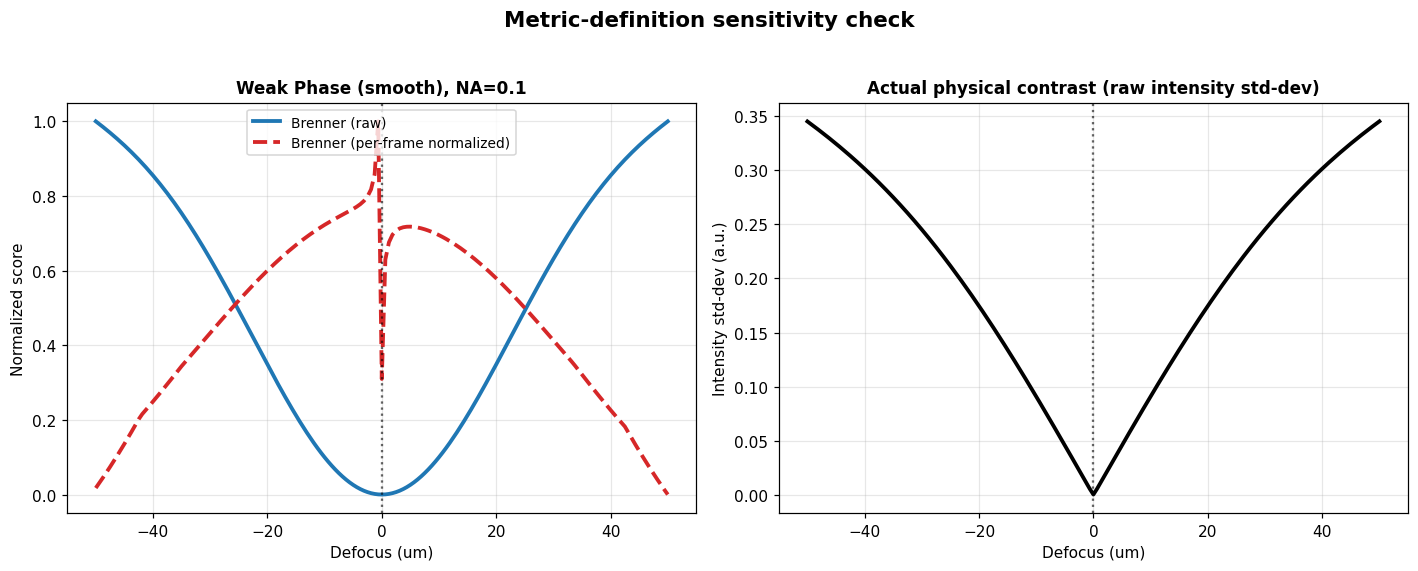

Physical contrast at true focus is 0.19% of the peak contrast in the sweep.
If this fraction is very small, per-frame normalization will still amplify near-zero-signal frames
to look comparable to genuinely sharp frames.


In [6]:
def brenner_raw(image):
    """Unnormalized, x-direction only"""
    return np.sum((image[2:, :] - image[:-2, :]) ** 2)

def brenner_normalized_per_frame(image):
    """Per-frame min-max normalized, both directions"""
    img_norm = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
    dx = np.sum((img_norm[2:, :] - img_norm[:-2, :]) ** 2)
    dy = np.sum((img_norm[:, 2:] - img_norm[:, :-2]) ** 2)
    return dx + dy

def sweep_metric(stack, metric_fn):
    scores = np.array([metric_fn(frame) for frame in stack])
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)

demo_name = "Weak Phase (smooth)"
demo_NA = 0.10
stack_demo = propagate_stack(objects_hr[demo_name], demo_NA, Z_ARRAY_UM)

raw_curve = sweep_metric(stack_demo, brenner_raw)
norm_curve = sweep_metric(stack_demo, brenner_normalized_per_frame)

# Also track the *actual physical contrast* (raw, un-rescaled std-dev) to show what normalization hides
true_contrast = np.array([frame.std() for frame in stack_demo])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(Z_ARRAY_UM, raw_curve, label="Brenner (raw)", color='tab:blue', lw=2.5)
axes[0].plot(Z_ARRAY_UM, norm_curve, label="Brenner (per-frame normalized)", color='tab:red', lw=2.5, ls='--')
axes[0].axvline(0, color='k', ls=':', alpha=0.6)
axes[0].set_title(f"{demo_name}, NA={demo_NA}", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Defocus (um)"); axes[0].set_ylabel("Normalized score")
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(Z_ARRAY_UM, true_contrast, color='black', lw=2.5)
axes[1].axvline(0, color='k', ls=':', alpha=0.6)
axes[1].set_title("Actual physical contrast (raw intensity std-dev)", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Defocus (um)"); axes[1].set_ylabel("Intensity std-dev (a.u.)")
axes[1].grid(alpha=0.3)

fig.suptitle("Metric-definition sensitivity check", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("fig_metric_definition_check.png", dpi=300, bbox_inches='tight')
plt.show()

focus_true_contrast = true_contrast[len(Z_ARRAY_UM)//2] / true_contrast.max()
print(f"Physical contrast at true focus is {focus_true_contrast*100:.2f}% of the peak contrast in the sweep.")
print("If this fraction is very small, per-frame normalization will still amplify near-zero-signal frames")
print("to look comparable to genuinely sharp frames.")

## 5. Main sweep: object type x NA, using the canonical (raw) Brenner metric

One consistent metric, one consistent defocus range, one consistent parameter set, all 6 object
types x 8 NA values.

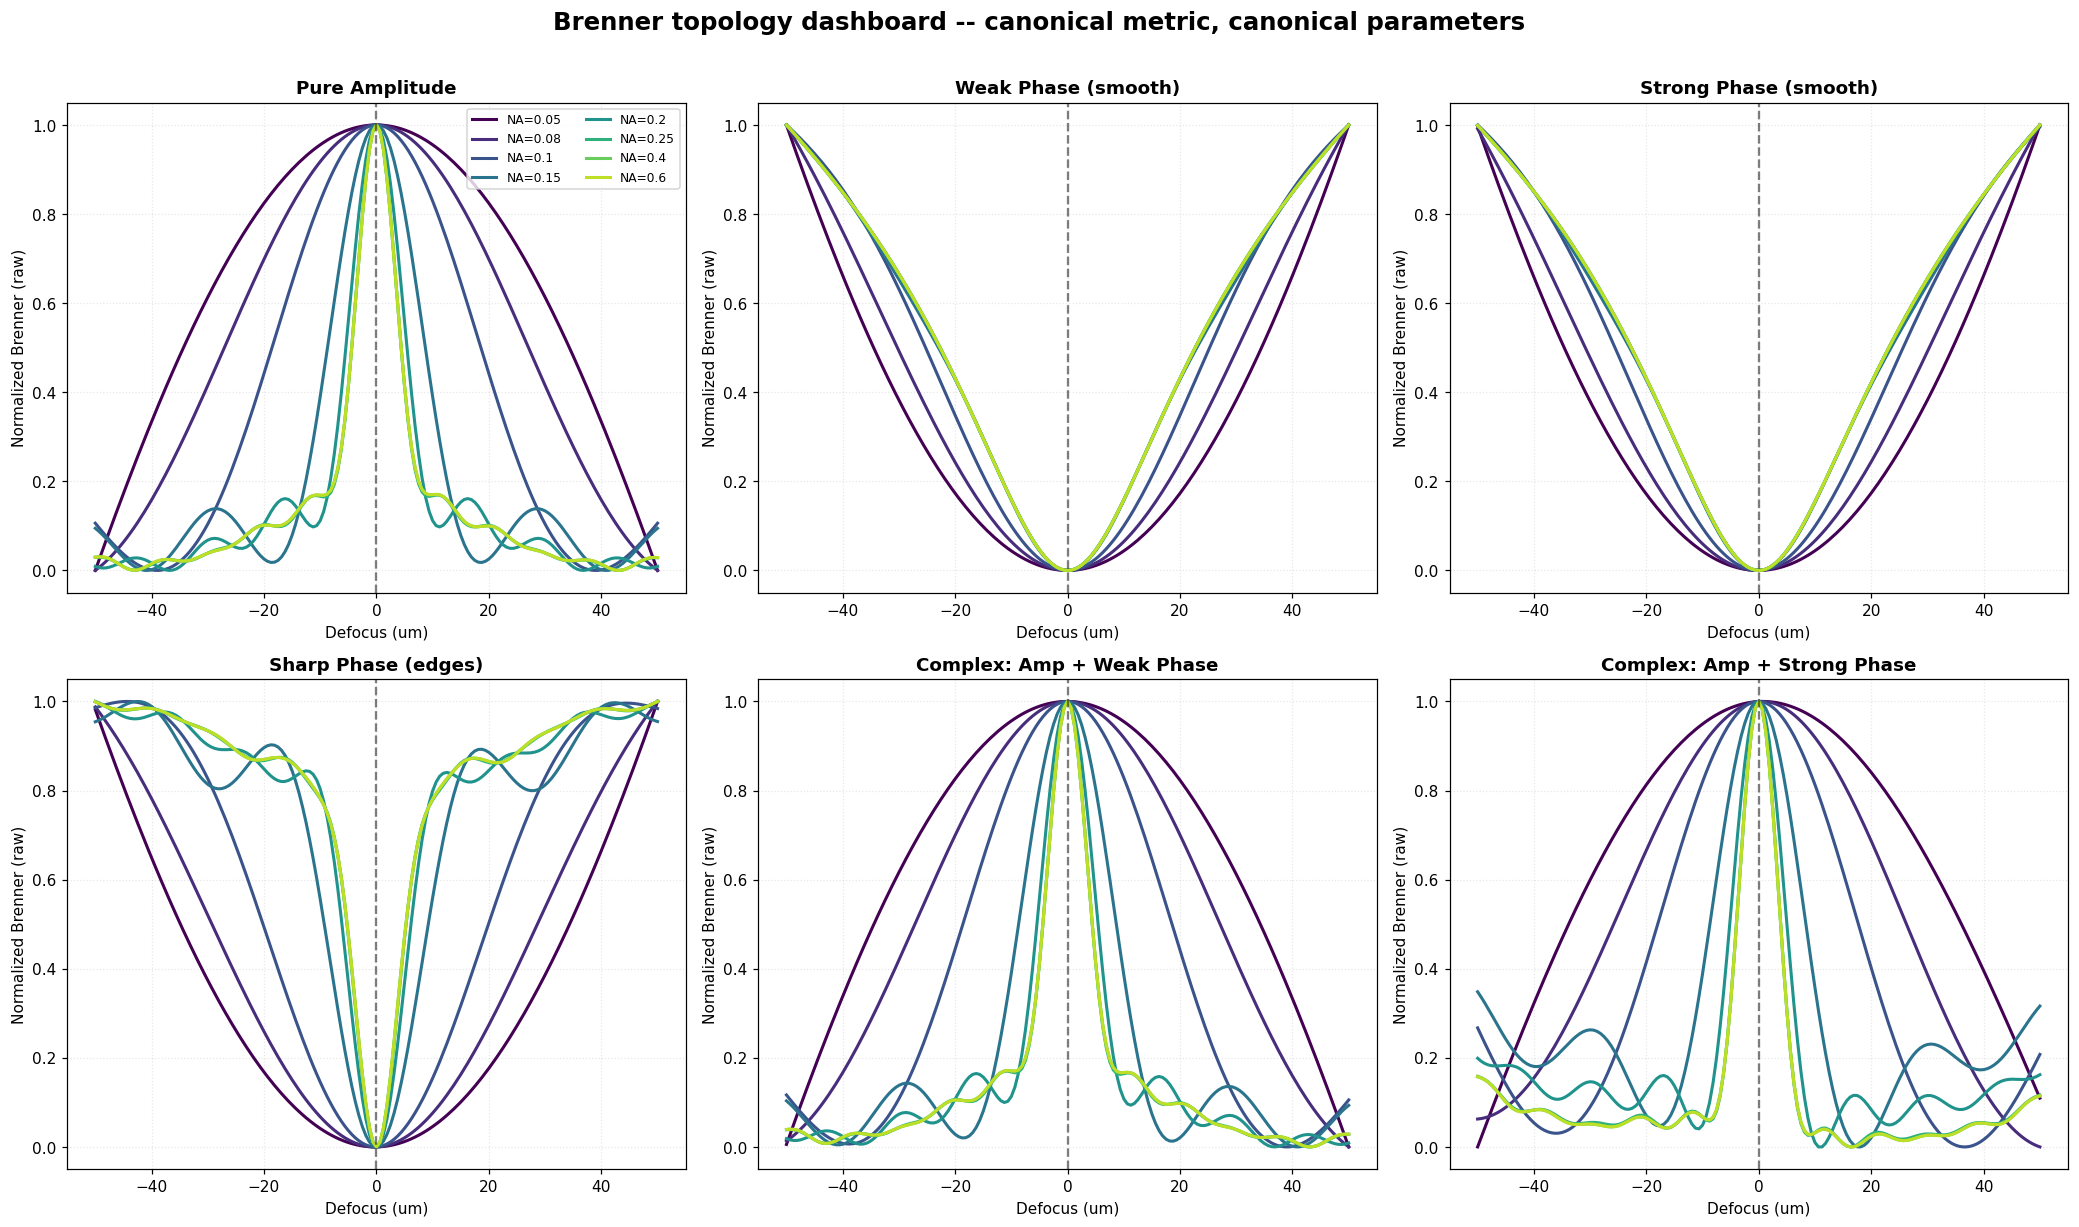

In [7]:
all_curves = {}
for name in object_names:
    all_curves[name] = {}
    for NA in NA_LIST:
        stack = propagate_stack(objects_hr[name], NA, Z_ARRAY_UM)
        all_curves[name][NA] = sweep_metric(stack, brenner_raw)

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()
na_colors = plt.cm.viridis(np.linspace(0, 0.9, len(NA_LIST)))#plasma, jet, twilight

for idx, name in enumerate(object_names):
    ax = axes[idx]
    for NA, c in zip(NA_LIST, na_colors):
        ax.plot(Z_ARRAY_UM, all_curves[name][NA], color=c, lw=2, label=f"NA={NA}")
    ax.axvline(0, color='k', ls='--', alpha=0.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3, ls=':')
axes[0].legend(loc='upper right', fontsize=8, ncol=2)
fig.suptitle("Brenner topology dashboard -- canonical metric, canonical parameters", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("figs/fig_main_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. Convergence study, is the high-NA anomaly real, or a simulation artifact?

We repeat the "Strong Phase" case at a fixed
physical NA and fixed physical camera pixel size, but increase the simulation oversampling
factor `ds` (and therefore `N_HR`). If the anomalous peak/dip behavior is real optics, the curve
shape should stabilize as `ds` increases. If it's a numerical artifact of insufficient FFT
padding, the curve will keep changing shape as `ds` grows.

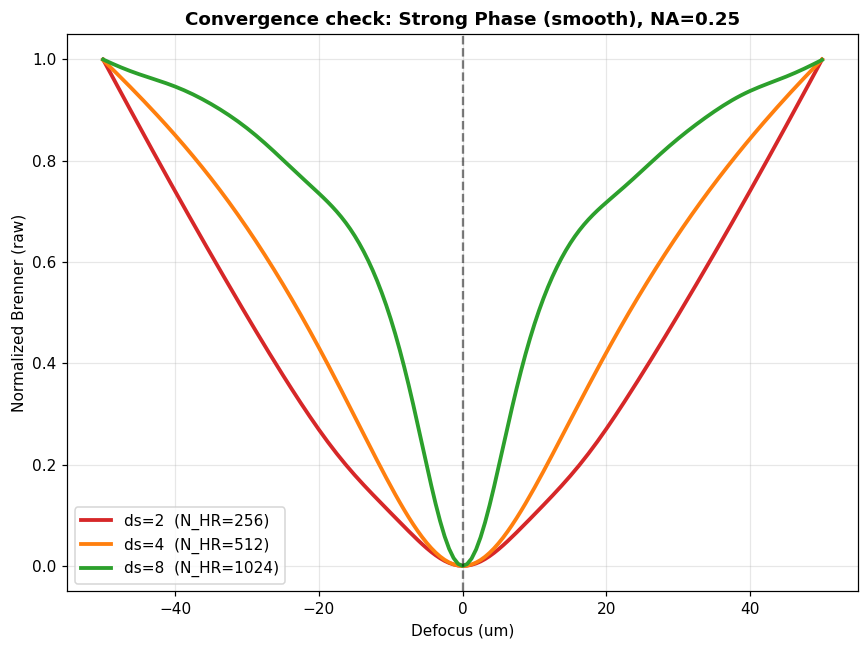

In [12]:
conv_NA = 0.25
conv_object_name = "Strong Phase (smooth)"
ds_list = [2, 4, 8]

fig, ax = plt.subplots(figsize=(8, 6))
conv_colors = ['tab:red', 'tab:orange', 'tab:green']

for ds_test, c in zip(ds_list, conv_colors):
    N_hr_test = N_LR * ds_test
    hr_pixel_test = EFF_PIXEL_UM / ds_test
    objs_test = make_objects(N_hr_test)

    fx_test = np.fft.fftshift(np.fft.fftfreq(N_LR, d=EFF_PIXEL_UM))
    FX_t, FY_t = np.meshgrid(fx_test, fx_test)
    pupil_t = (np.sqrt(FX_t**2 + FY_t**2) <= conv_NA / WAVELENGTH_UM).astype(float)
    radicand_t = np.maximum((1/WAVELENGTH_UM)**2 - FX_t**2 - FY_t**2, 0)
    kz_t = 2*np.pi*np.sqrt(radicand_t)

    cy_t, cx_t = N_hr_test//2, N_hr_test//2
    ys_t, ye_t = cy_t - N_LR//2, cy_t + N_LR//2
    xs_t, xe_t = cx_t - N_LR//2, cx_t + N_LR//2

    O_fft = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(objs_test[conv_object_name])))
    O_crop = O_fft[ys_t:ye_t, xs_t:xe_t]

    scores = []
    for z in Z_ARRAY_UM:
        pupil_z = pupil_t * np.exp(1j * z * kz_t)
        E_f = O_crop * pupil_z
        E_s = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_f)))
        scores.append(brenner_raw(np.abs(E_s)**2))
    scores = np.array(scores)
    norm = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
    ax.plot(Z_ARRAY_UM, norm, color=c, lw=2.5, label=f"ds={ds_test}  (N_HR={N_hr_test})")

ax.axvline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
ax.set_title(f"Convergence check: {conv_object_name}, NA={conv_NA}",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig_convergence_check.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Noise robustness — does the metric actually survive real camera noise?

the two-pixel-offset Brenner gradient bridges over high-frequency camera
read-noise or speckle noise. That claim has never been tested against simulated noise. Here we
add Poisson noise at a few photon-budget levels to one  case and see whether
the curve shape / focus location survives.

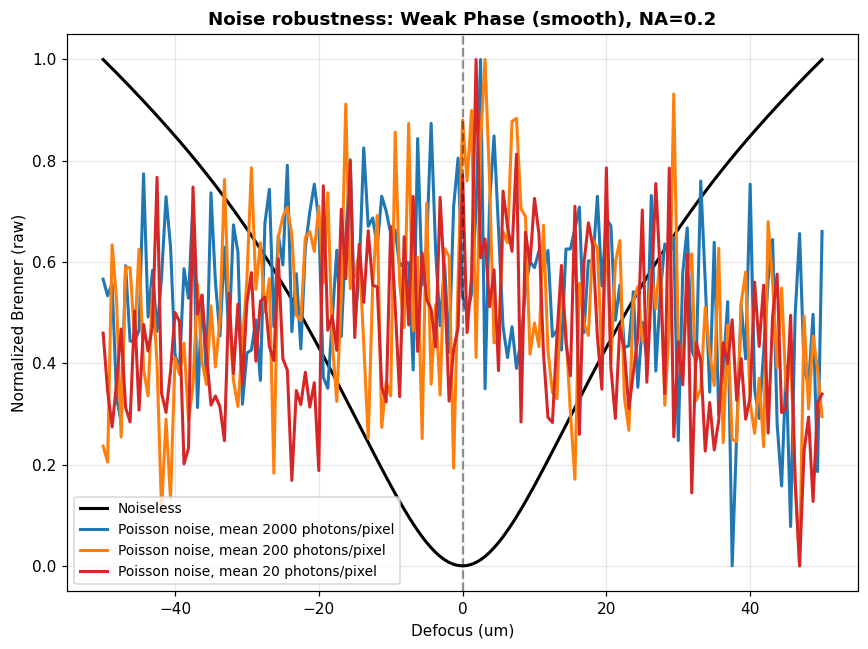

In [13]:
def add_shot_noise(intensity_frame, mean_photon_count):
    scaled = intensity_frame / (intensity_frame.max() + 1e-12) * mean_photon_count
    noisy = np.random.poisson(np.clip(scaled, 0, None)).astype(float)
    return noisy

noise_object = "Weak Phase (smooth)"
noise_NA = 0.20
stack_noise = propagate_stack(objects_hr[noise_object], noise_NA, Z_ARRAY_UM)

photon_budgets = [None, 2000, 200, 20]  # None = noiseless
fig, ax = plt.subplots(figsize=(8, 6))
noise_colors = ['black', 'tab:blue', 'tab:orange', 'tab:red']
for budget, c in zip(photon_budgets, noise_colors):
    if budget is None:
        curve = sweep_metric(stack_noise, brenner_raw)
        label = "Noiseless"
    else:
        noisy_stack = np.array([add_shot_noise(f, budget) for f in stack_noise])
        curve = sweep_metric(noisy_stack, brenner_raw)
        label = f"Poisson noise, mean {budget} photons/pixel"
    ax.plot(Z_ARRAY_UM, curve, color=c, lw=2, label=label)

ax.axvline(0, color='k', ls='--', alpha=0.4)
ax.set_xlabel("Defocus (um)"); ax.set_ylabel("Normalized Brenner (raw)")
ax.set_title(f"Noise robustness: {noise_object}, NA={noise_NA}", fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figs/fig_noise_robustness.png", dpi=150, bbox_inches='tight')
plt.show()